![Logo](https://raw.githubusercontent.com/sadiam09/Beginner/main/logo.PNG)
# M32895 Big Data Applications (Main Coursework)
## UP2089630 Sadia Maio
## 2025/6
---

### Notebook Objectives
* Load and Validate the Bikesharing dataset from Kaggle (DONE)
* Perform Exploratory Data Analysis (EDA) to understand the data
* Build and train two ML models: Linear regression and Decision Tree Regressor
* Evaluate and compare model performance using R2, MAE, MSE and RMSE
* Predict bike rental demand on new data from input

### Inputs
* Dataset: `../datasets/hour.csv` downloaded from Kaggle using the Kaggle API

### Outputs
* Trained models saved in `../models/` folder

---
### <u>Data Collection</u>

In [ ]:
"""
Download Bike Sharing Dataset
from Kaggle using the Kaggle API
"""
import kaggle

# Authenticate using Kaggle API token stored in ~/.kaggle/access_token
kaggle.api.authenticate()

# Download and unzip dataset into datasets folder
kaggle.api.dataset_download_files(
    'lakshmi25npathi/bike-sharing-dataset',
    path='../datasets/',
    unzip=True
)

print("Dataset downloaded successfully")

---

### <u>Import Libraries</u>

In [2]:
"""
Import all required libraries
and modules for the ML pipeline
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib
import os

In [3]:
"""
Configure visualisation
for consistent plot styling
"""
sns.set_style('darkgrid')

---

### <u>Data Loading and Validation</u>

In [4]:
"""
Load the Bike Sharing dataset
from the datasets folder
"""
# load hourly bike sharing data
df = pd.read_csv('../datasets/hour.csv')

In [5]:
"""
Inspect the dataset
"""
# display first 5 rows
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [6]:
# display dataset info including column types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


In [7]:
# display a summary of the dataset
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [8]:
# check for missing values in each column
df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [9]:
# drop rows with missing values (for presentation purposes as this datatset clearly has no missing values)
df = df.dropna()

# confirm no missing values remain
df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

---

### <u>Exploratory Data Analysis (EDA)<u>

In [10]:
"""
Explore the dataset to understand
the structure and the contents within it
"""

# display first 5 rows again to display how the dataset looks currently
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [11]:
# display number of rows and columns (returned as a tuple)
df.shape

(17379, 17)

In [12]:
# display bike rental count distribution in a histogram
fig = px.histogram(
    df,  # datatset
    x='cnt',  # bike rental count on x axis
    marginal='box',
    title='Bike Rental Count Distribution'
)
fig.update_layout(bargap=0.1)  # add gaps between bars
fig.show()  # display chart

In [13]:
# display distribution of temperature in a histogram
fig = px.histogram(
    df,
    x='temp',
    marginal='box',
    title='Temperature Distribution'
)
fig.update_layout(bargap=0.1)
fig.show()

In [14]:
# display bike rentals by season in a bar chart
fig = px.histogram(
    df,
    x='season',
    color='season',  # colour bars by season
    title='Bike Rentals by Season'
)
fig.show()

In [15]:
# display bike rentals vs temperature on a scatter plot
fig = px.scatter(
    df,
    x='temp',  # temperature on x axis
    y='cnt',  # bike rentals on y axis
    color='season',
    opacity=0.8,  # point transparency
    title='Temperature vs Bike Rentals'
)
fig.update_traces(marker_size=5)  # point size
fig.show()

In [16]:
# check correlation between features
df.select_dtypes(include='number').corr()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
instant,1.000000,0.404046,0.866014,0.489164,-0.004775,0.014723,0.001357,-0.003416,-0.014198,0.136178,0.137615,0.009577,-0.074505,0.158295,0.282046,0.278379
season,0.404046,1.000000,-0.010742,0.830386,-0.006117,-0.009585,-0.002335,0.013743,-0.014524,0.312025,0.319380,0.150625,-0.149773,0.120206,0.174226,0.178056
yr,0.866014,-0.010742,1.000000,-0.010473,-0.003867,0.006692,-0.004485,-0.002196,-0.019157,0.040913,0.039222,-0.083546,-0.008740,0.142779,0.253684,0.250495
mnth,0.489164,0.830386,-0.010473,1.000000,-0.005772,0.018430,0.010400,-0.003477,0.005400,0.201691,0.208096,0.164411,-0.135386,0.068457,0.122273,0.120638
hr,-0.004775,-0.006117,-0.003867,-0.005772,1.000000,0.000479,-0.003498,0.002285,-0.020203,0.137603,0.133750,-0.276498,0.137252,0.301202,0.374141,0.394071
holiday,0.014723,-0.009585,0.006692,0.018430,0.000479,1.000000,-0.102088,-0.252471,-0.017036,-0.027340,-0.030973,-0.010588,0.003988,0.031564,-0.047345,-0.030927
weekday,0.001357,-0.002335,-0.004485,0.010400,-0.003498,-0.102088,1.000000,0.035955,0.003311,-0.001795,-0.008821,-0.037158,0.011502,0.032721,0.021578,0.026900
workingday,-0.003416,0.013743,-0.002196,-0.003477,0.002285,-0.252471,0.035955,1.000000,0.044672,0.055390,0.054667,0.015688,-0.011830,-0.300942,0.134326,0.030284
weathersit,-0.014198,-0.014524,-0.019157,0.005400,-0.020203,-0.017036,0.003311,0.044672,1.000000,-0.102640,-0.105563,0.418130,0.026226,-0.152628,-0.120966,-0.142426
temp,0.136178,0.312025,0.040913,0.201691,0.137603,-0.027340,-0.001795,0.055390,-0.102640,1.000000,0.987672,-0.069881,-0.023125,0.459616,0.335361,0.404772


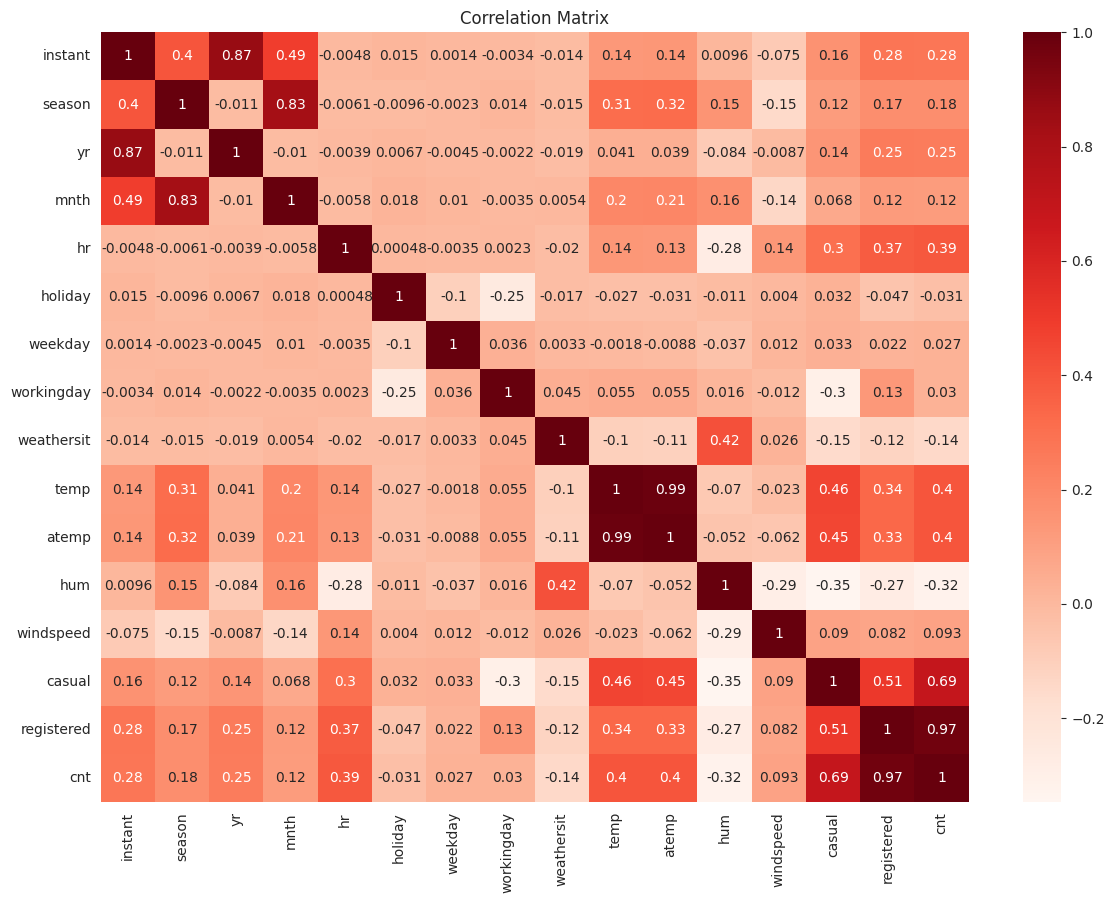

In [17]:
# heatmap showing correlation between features
plt.figure(figsize=(14, 10))  # fig size to avoid overlapping
sns.heatmap(
    df.select_dtypes(include='number').corr(),  # numerical columns
    cmap='Reds',  # colour scheme
    annot=True
)
plt.title('Correlation Matrix')
plt.show()

---

### <u>Data Preparation<u>

In [18]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='str')

In [19]:
"""
Drop columns that are not
useful for prediction
"""

df = df.drop(columns=[
    'instant',  # row index, not useful for prediction
    'dteday',  # date column, not useful for prediction
    'casual',  # casual + registered = cnt, keeping them would give the model the answer
    'registered'
])

# confirm changes
df.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


## References

*(https://www.kaggle.com/docs/api)
*(https://plotly.com/python-api-reference/generated/plotly.express.scatter)
*(https://plotly.com/python-api-reference/generated/plotly.express.histogram.html)
*(https://seaborn.pydata.org/generated/seaborn.heatmap.html)
*()